In [2]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, mean_squared_error
from sklearn.metrics import classification_report

In [4]:
music_df= pd.read_csv("../Week10/Resources/music.csv")
music_dummy = pd.get_dummies(music_df["genre"], drop_first= True)
print(music_dummy.head())

   Anime  Blues  Classical  Country  Electronic  Hip-Hop   Jazz    Rap   Rock
0  False  False      False    False       False    False   True  False  False
1  False  False      False    False       False    False  False   True  False
2  False  False      False    False        True    False  False  False  False
3  False  False      False    False       False    False  False  False   True
4  False  False      False    False       False    False  False   True  False


In [7]:
music_dummy = pd.concat([music_df, music_dummy], axis = 1)
music_dummy = music_dummy.drop("genre", axis = 1)
print(music_dummy)

     Unnamed: 0  popularity  acousticness  danceability  duration_ms  energy  \
0             0          41      0.644000         0.823     237000.0   0.814   
1             1          62      0.085500         0.686     154000.0   0.670   
2             2          42      0.239000         0.669     218000.0   0.736   
3             3          64      0.012500         0.522     246000.0   0.923   
4             4          60      0.121000         0.780     229000.0   0.467   
..          ...         ...           ...           ...          ...     ...   
995         995          65      0.000983         0.531     216000.0   0.855   
996         996          38      0.033200         0.608     219000.0   0.938   
997         997          56      0.005790         0.939     145000.0   0.373   
998         998          64      0.250000         0.546     178000.0   0.631   
999         999          61      0.072500         0.641         -1.0   0.792   

     instrumentalness  liveness  loudne

In [9]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
x = music_dummy.drop("popularity", axis = 1).values
y = music_dummy["popularity"].values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state= 42)
kf = KFold(n_splits = 5, shuffle = True, random_state= 42)
linreg = LinearRegression()
linreg_cv = cross_val_score(linreg, x_train, y_train, cv = kf, scoring = "neg_mean_squared_error")
print(np.sqrt(-linreg_cv))

[8.14828914 8.63267535 7.56370022 8.61139914 7.91041513]


In [13]:
music_df = pd.read_csv('../Week10/Resources/music_unclean.csv', index_col = 0)
print(music_df.isna().sum().sort_values())

genre                 8
popularity           31
loudness             44
liveness             46
tempo                46
speechiness          59
instrumentalness     91
duration_ms          91
danceability        143
valence             143
energy              200
acousticness        200
dtype: int64


In [14]:
music_df = music_df.dropna(subset = ["genre", "popularity", "loudness", "liveness", "tempo"])
print(music_df.isna().sum().sort_values())

popularity            0
loudness              0
liveness              0
tempo                 0
genre                 0
duration_ms          29
instrumentalness     29
speechiness          53
danceability        127
valence             127
energy              178
acousticness        178
dtype: int64


In [18]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

x_cat = music_df["genre"].values.reshape(-1,1)
x_num = music_df.drop(["genre", "popularity"], axis = 1).values
y = music_df["popularity"].values

x_train_cat, x_test_cat, y_train, y_test = train_test_split(x_cat, y, test_size = 0.2, random_state= 12)
x_train_num, x_test_num, y_train, y_test = train_test_split(x_num, y, test_size = 0.2, random_state= 12)

# Impute categorical data
imp_cat = SimpleImputer(strategy="most_frequent")
x_train_cat = imp_cat.fit_transform(x_train_cat)
x_test_cat = imp_cat.transform(x_test_cat)

# Impute numerical data
imp_num = SimpleImputer()
x_train_num = imp_num.fit_transform(x_train_num)
x_test_num = imp_num.transform(x_test_num)

# Encode categorical data (convert strings to numbers)
encoder = OneHotEncoder(sparse_output=False)
x_train_cat_encoded = encoder.fit_transform(x_train_cat)
x_test_cat_encoded = encoder.transform(x_test_cat)

# Combine numerical and encoded categorical features
x_train = np.append(x_train_num, x_train_cat_encoded, axis = 1)
x_test = np.append(x_test_num, x_test_cat_encoded, axis = 1)

knn = KNeighborsClassifier(n_neighbors= 5)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
print(knn.score(x_test, y_test))

0.0111731843575419


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
music_df = pd.read_csv('../Week10/Resources/music_unclean.csv', index_col = 0)
music_df = music_df.dropna(subset = ["genre", "popularity", "loudness", "liveness", "tempo"])
music_df["genre"] = np.where(music_df["genre"] == "Rock", 1, 0)
x = music_df.drop("genre", axis = 1).values
y = music_df["genre"].values 

steps = [('imputation', SimpleImputer()),
         ('Log_reg', LogisticRegression(max_iter = 100000))]
pipeline = Pipeline(steps)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
pipeline.fit(x_train, y_train)
pipeline.score(x_test, y_test)

y_pred = pipeline.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(pipeline.score(x_test, y_test))

[[104  31]
 [ 11 122]]
0.8432835820895522


In [26]:
music_df = pd.read_csv("../Week10/Resources/music_unclean.csv")

music_df = music_df.dropna(subset=["genre", "popularity", "loudness", "liveness", "tempo"])

print(music_df.isna().sum().sort_values())
print("Shape of the `music_df`: {}".format(music_df.shape))

# Convert genre to a binary feature
music_df["genre"] = np.where(music_df["genre"] == "Rock", 1, 0)

X = music_df.drop('genre', axis = 1).values
y = music_df['genre'].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)
# Instantiate an imputer
imputer = SimpleImputer()
X_train = imputer.fit_transform(X_train) ###################
X_test = imputer.transform(X_test)          ###################

# Instantiate a knn model
knn = KNeighborsClassifier(n_neighbors=3)

# Build steps for the pipeline
steps = [("imputer", imputer), 
         ("knn", knn)]

# Create the pipeline
pipeline = Pipeline(steps)

# Fit the pipeline to the training data
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Print the confusion matrix

print(confusion_matrix(y_test, y_pred))
print(pipeline.score(X_test,y_test))

#print(X_train.shape)
columns = ['acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'valence', 'genre', 'popularity']
check = pd.DataFrame(X_train, columns = columns)
print(check.isna().sum().sort_values())


Unnamed: 0            0
popularity            0
liveness              0
loudness              0
tempo                 0
genre                 0
instrumentalness     29
duration_ms          29
speechiness          53
valence             127
danceability        127
acousticness        178
energy              178
dtype: int64
Shape of the `music_df`: (892, 13)
[[69 66]
 [66 67]]
0.5074626865671642


ValueError: Shape of passed values is (624, 12), indices imply (624, 11)

Finding Best K for test_size=0.2


Finding Best K for test_size=0.2


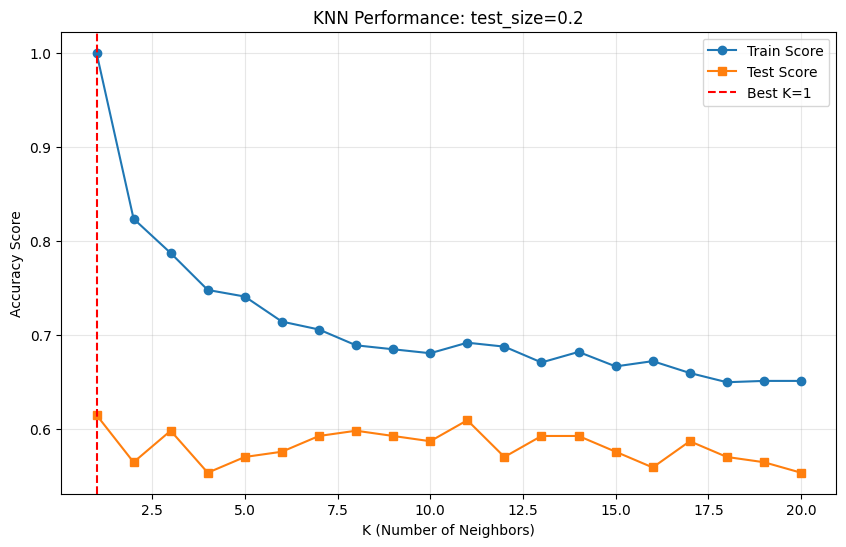

Finding Best K for test_size=0.2


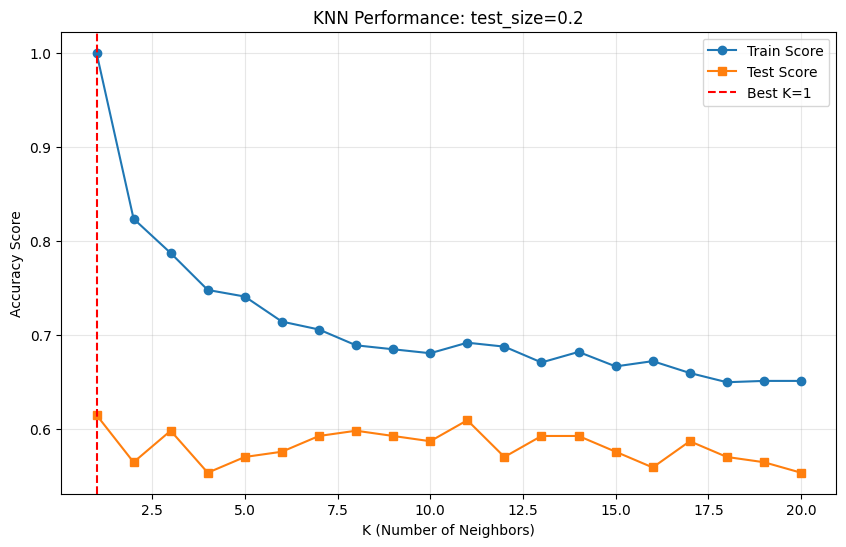


=== Results for test_size=0.2 ===
Best K: 1
Best Test Accuracy: 0.6145
Train Accuracy at Best K: 1.0000

Confusion Matrix (K=1):
[[52 42]
 [27 58]]

Finding Best K for test_size=0.3


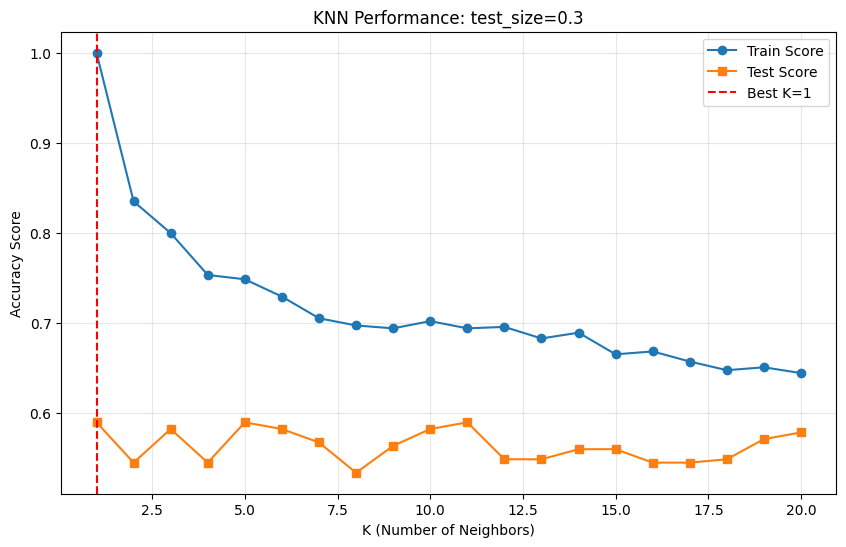


=== Results for test_size=0.3 ===
Best K: 1
Best Test Accuracy: 0.5896
Train Accuracy at Best K: 1.0000

Confusion Matrix (K=1):
[[72 63]
 [47 86]]

SUMMARY COMPARISON
test_size=0.2: Best K=1, Accuracy=0.6145
test_size=0.3: Best K=1, Accuracy=0.5896

Best Configuration: test_size=0.2 with K=1
